In [1]:
import gymnasium as gym
import numpy as np
import stable_baselines3 as sb3
from stable_baselines3 import PPO
import mujoco
import matplotlib.pyplot as plt
from stable_baselines3.common.monitor import Monitor
from pathlib import Path
import pandas as pd
from time import sleep



In [2]:
path = Path("temp")
path.mkdir(parents=False, exist_ok=True)

In [ ]:
env = gym.make('HalfCheetah-v5')
env = Monitor(env, "temp")
model = PPO(
    "MlpPolicy",
    env)

model.learn(total_timesteps=1000000)

# 4. Save the model
model.save("ppo_halfcheetah")

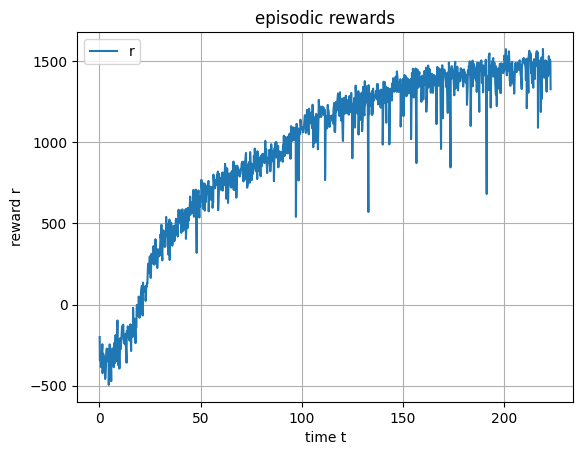

In [21]:
# Load the data
df = pd.read_csv(path /'monitor.csv', header=1)

df.head(5)

# Create the plot
df.plot(x='t', y='r')

# Customize and show
plt.title('episodic rewards')
plt.xlabel('time t')
plt.ylabel('reward r')
plt.grid(True)
plt.show()

In [2]:
env = gym.make('HalfCheetah-v5')
state, _ = env.reset()
model = PPO.load("ppo_halfcheetah")

for i in range(100):
    action, _ = model.predict(state)
    print(state[0])
    state, reward, terminated, truncated, _  = env.step(action)
    sleep(0.1)
    if terminated or truncated:
        state, _ = env.reset()


env.close()

0.03520166363651469
0.012123180536990748
-0.04052672731078936
-0.10490096615937095
-0.163347547498609
-0.15490008013463577
-0.08225210215602181
-0.012890840301884537
0.016053391959956868
-0.00625091555425264
0.007638914656036992
0.05321946279111336
0.0777447467595252
0.08320098129658937
0.09070621713773991
0.07702471280247777
0.12659314915308675
0.2280318508029423
0.3074124550609265
0.2994165263387925
0.27080795857799755
0.26729519611141406
0.22165410845183897
0.1223713041619191
0.0905853985603678
0.10553256434793373
0.02406760371889685
-0.008167153156730673
-0.03781154110381696
-0.11913843020131991
-0.23188656162415877
-0.3183379542108857
-0.4287862672969472
-0.5232965109729749
-0.5809882593888791
-0.554303605805523
-0.5106821842457013
-0.5082841212731046
-0.46824123770798787
-0.45154354698554666
-0.5195210530071933
-0.5263071031799755
-0.49356145265593604
-0.4905565744183297
-0.5230795443107914
-0.5028026071062832
-0.5312938857574777
-0.5706871684534286
-0.5377584499447565
-0.4991948

In [ ]:
class customReward(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        
        new_reward = -reward + obs[0]
        
        return obs, new_reward, terminated, truncated, info

# Usage

env = gym.make('HalfCheetah-v5')
env = customReward(env)


env = Monitor(env, "temp/monitor3.csv")
model = PPO(
    "MlpPolicy",
    env)

model.learn(total_timesteps=1000000)

# 4. Save the model
model.save("ppo_halfcheetah_3")

In [10]:
custom_xml_path = "deform_half_cheetah.xml"
env = gym.make('HalfCheetah-v5', render_mode = "human", xml_file=custom_xml_path)

try:
    state, _ = env.reset()
    model = PPO.load("ppo_halfcheetah_new")

    for i in range(1000):
        action, _ = model.predict(state)
        #print(state[8])
        state, reward, terminated, truncated, _  = env.step(action)
        sleep(0.1)
        if terminated or truncated:
            break
except KeyboardInterrupt:
    print("Simulation interrupted by user.")

finally:
    env.close()  

Simulation interrupted by user.
